# Estimating the chirp mass of GW150914

In the notes we derived the leading-order inspiral law

$$\omega^{-8/3} = \frac{256}{5} M_c^{5/3} (t_c - t),$$

which says that if we plot $\omega^{-8/3}$ against time we should get a **straight line**, with a slope that depends only on the chirp mass $M_c$. Everything else drops out at this order, and indeed $M_c$ is the best-measured parameter of any inspiral.

Here we estimate $M_c$ for GW150914 by reading off the zero crossings of the Hanford (H1) waveform off the plot, converting them to instantaneous frequencies, and fitting a straight line. Keep in mind:

- The gravitational-wave frequency is **twice** the orbital frequency, because the mass quadrupole returns to its initial configuration after half an orbit. So $\omega_{\rm gw} = 2\omega_{\rm orb}$.
- Successive zero crossings are separated by **half** a gravitational-wave period, not a whole one.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

## 1. Reading the waveform

We look at `gw150914.png`, top-left panel (H1 observed). We start where the signal first rises clearly above the noise — around $t \simeq 0.36\,$s — follow the red curve and note each time it crosses zero. We stop at the point of maximum amplitude, near $t \simeq 0.43\,$s: after that the binary has merged and the simple inspiral formula no longer applies. The values below were read off the figure to the nearest millisecond.

![H1 strain with zero crossings](gw150914-h1-crossings.png) 

In [2]:
# Zero crossings of the H1 strain, read by eye from gw150914.png (seconds)
t_cross = np.array([
    0.358, 0.367, 0.377, 0.388, 0.397,
    0.404, 0.411, 0.416, 0.421, 0.424, 0.427,
])

print(f"{len(t_cross)} crossings, spanning {t_cross[0]:.3f} to {t_cross[-1]:.3f} s")

11 crossings, spanning 0.358 to 0.427 s


## 2. From crossings to instantaneous frequency

Consecutive zero crossings are half a period apart, so the gravitational-wave frequency between two crossings is

$$f_{\rm gw} = \frac{1}{2\,\Delta t}.$$

We assign each frequency to the midpoint of the interval it was measured over.

In [3]:
dt = np.diff(t_cross)
f_gw = 1.0 / (2.0 * dt)                     # GW frequency in Hz
t_mid = 0.5 * (t_cross[:-1] + t_cross[1:])  # fiducial time for each frequency

for tm, f in zip(t_mid, f_gw):
    print(f"t = {tm:.4f} s    f_gw = {f:6.1f} Hz")

t = 0.3625 s    f_gw =   55.6 Hz
t = 0.3720 s    f_gw =   50.0 Hz
t = 0.3825 s    f_gw =   45.5 Hz
t = 0.3925 s    f_gw =   55.6 Hz
t = 0.4005 s    f_gw =   71.4 Hz
t = 0.4075 s    f_gw =   71.4 Hz
t = 0.4135 s    f_gw =  100.0 Hz
t = 0.4185 s    f_gw =  100.0 Hz
t = 0.4225 s    f_gw =  166.7 Hz
t = 0.4255 s    f_gw =  166.7 Hz


The frequency climbs from roughly 50 Hz to well over 150 Hz in about seventy milliseconds. The sequence is not perfectly monotonic: reading crossings by eye is an imprecise business!

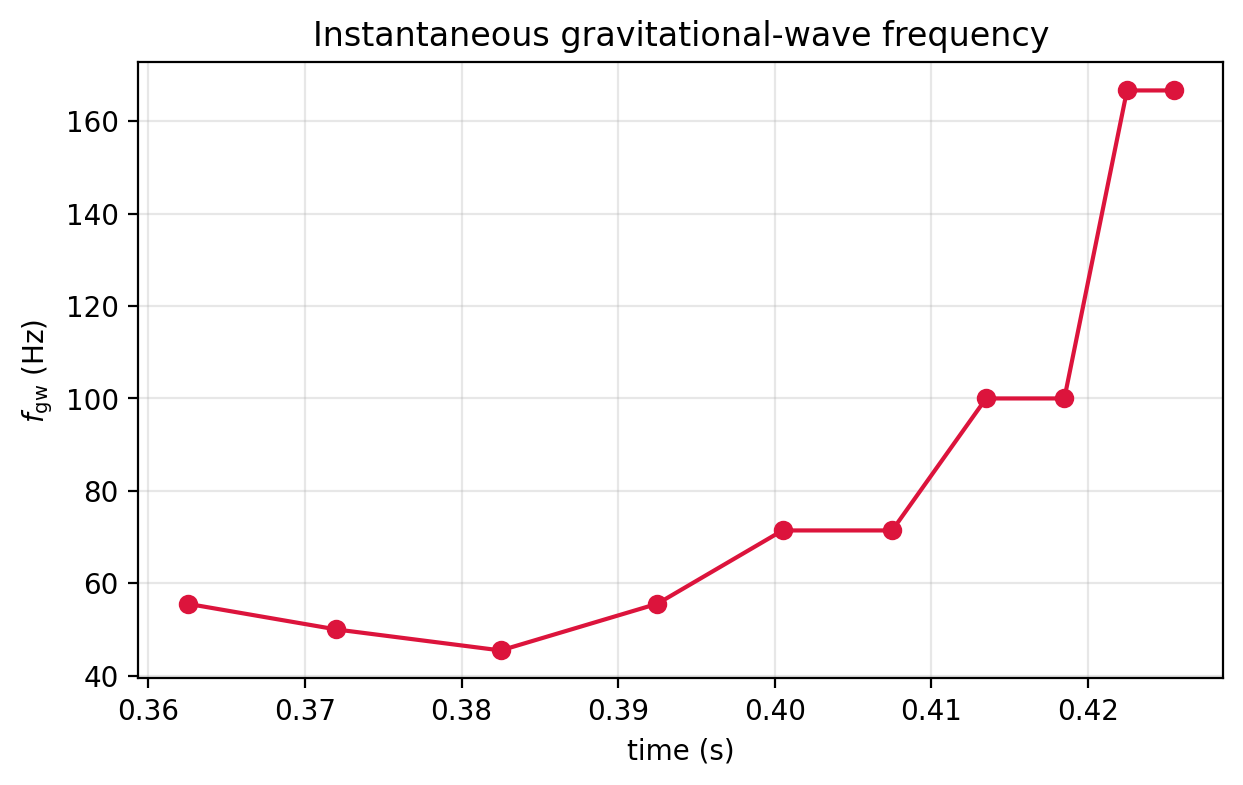

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_mid, f_gw, "o-", color="crimson")
ax.set_xlabel("time (s)")
ax.set_ylabel(r"$f_{\rm gw}$ (Hz)")
ax.set_title("Instantaneous gravitational-wave frequency")
ax.grid(alpha=0.3)
plt.show()

## 3. The linearizing transformation

Now the key step. With $\omega_{\rm gw} = 2\pi f_{\rm gw}$, the inspiral law predicts that

$$f_{\rm gw}^{-8/3} \propto (t_c - t),$$

so plotting $f_{\rm gw}^{-8/3}$ against $t$ should give a descending straight line that hits zero at the coalescence time $t_c$. This is a good example of a general strategy: rather than fitting a complicated curve, find the transformation that makes the relationship linear, then fit a line.

In [5]:
# y = ...

# TODO: Fit a straight line with np.polyfit
# slope, intercept = np.polyfit(..., ..., 1)

# t_c = ...

# TODO: Print the fitted parameters and coalescence time
print(f"slope     = {slope:.6e} s^(-5/3)")
print(f"intercept = {intercept:.6e}")
print(f"coalescence time t_c = {t_c:.4f} s")


NameError: name 'slope' is not defined

NameError: name 'y' is not defined

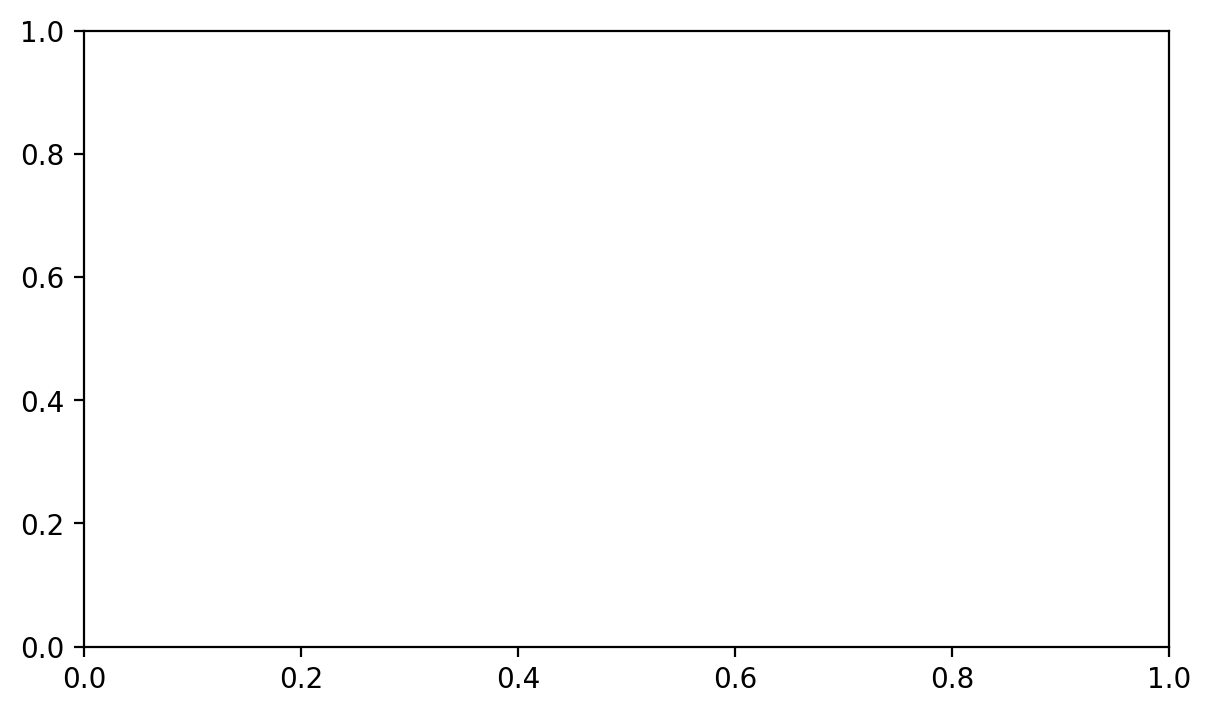

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_mid, y, "o", color="crimson", label="from zero crossings")

tt = np.linspace(t_mid[0], t_c, 100)
ax.plot(tt, slope * tt + intercept, "-", color="black", lw=1,
        label=f"linear fit ($t_c$ = {t_c:.3f} s)")

ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("time (s)")
ax.set_ylabel(r"$f_{\rm gw}^{-8/3}$  (s$^{8/3}$)")
ax.set_title("The inspiral linearized")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The points do fall close to a line — which is already a non-trivial confirmation of the $-8/3$ power law, and therefore of the quadrupole formula that produced it.

## 4. Extracting the chirp mass

To turn the slope into a mass we need the constant of proportionality. Starting from
$\omega_{\rm orb}^{-8/3} = \frac{256}{5} M_c^{5/3}(t_c - t)$ in geometrized units, and substituting
$\omega_{\rm orb} = \pi f_{\rm gw}$ (recall $\omega_{\rm gw} = 2\omega_{\rm orb}$, so $\omega_{\rm orb} = \tfrac{1}{2}\cdot 2\pi f_{\rm gw}$), we get

$$f_{\rm gw}^{-8/3} = \frac{256\,\pi^{8/3}}{5} M_c^{5/3} (t_c - t).$$

So the magnitude of our fitted slope is $\frac{256\,\pi^{8/3}}{5} M_c^{5/3}$, and

$$M_c = \left[ \frac{5}{256\,\pi^{8/3}} \, |{\rm slope}| \right]^{3/5}.$$

We compute this first in geometrized units, where $M_c$ comes out as a **time**, and then convert.

In [10]:
M_SUN_SECONDS = 4.925e-6     # one solar mass in geometrized units (seconds)

Mc_seconds = (abs(slope) * 5.0 / (256.0 * np.pi ** (8.0 / 3.0))) ** (3.0 / 5.0)
Mc_solar = Mc_seconds / M_SUN_SECONDS

print(f"M_c = {Mc_seconds:.3e} s")
print(f"M_c = {Mc_solar:.1f} solar masses")

M_c = 1.585e-04 s
M_c = 32.2 solar masses


As a check, the same calculation carried out in SI units, which is more tedious but avoids the geometrized-unit sleight of hand:

$$M_c = \frac{c^3}{G}\left[ \frac{5}{256\,\pi^{8/3}}\,|{\rm slope}| \right]^{3/5}.$$

In [11]:
G = 6.674e-11        # m^3 kg^-1 s^-2
c = 2.998e8          # m/s
M_SUN = 1.989e30     # kg

Mc_kg = (c ** 3 / G) * (abs(slope) * 5.0 / (256.0 * np.pi ** (8.0 / 3.0))) ** (3.0 / 5.0)

print(f"M_c = {Mc_kg:.3e} kg")
print(f"M_c = {Mc_kg / M_SUN:.1f} solar masses")

M_c = 6.399e+31 kg
M_c = 32.2 solar masses


## 5. What we have learned

The published LIGO value is $M_c \simeq 30\,M_\odot$. We are within a few solar masses of it, having used nothing but a ruler applied to a figure.

If we now *assume* the two black holes had equal masses, then $\mu = m/2$ and $M = 2m$, so
$M_c = \mu^{3/5}M^{2/5} = 2^{-1/5} m$, giving:

In [12]:
m_equal = Mc_solar * 2 ** (1.0 / 5.0)
print(f"if m1 = m2, then each black hole has m = {m_equal:.1f} solar masses")

if m1 = m2, then each black hole has m = 37.0 solar masses


Two stellar-mass black holes of roughly thirty-odd solar masses each — which is what the collaboration concluded, and which was itself a surprise, since black holes this heavy were not known to exist before GW150914.

### Things to try (if you wish)

1. **Re-read the crossings yourself** and re-run the notebook. How much does $M_c$ move? This is your systematic uncertainty, and it is much larger than any formal error from `polyfit`.
2. **Drop the last two or three crossings.** These are closest to merger, where the leading-order formula is least reliable (the post-Newtonian parameter $\mathcal{C} = M/r$ is no longer small). Does the fit improve or degrade?
3. **Weight the fit.** The early crossings are more widely spaced and therefore give more precise frequencies. Try `np.polyfit(..., w=...)` and see whether it helps.
4. **Predict the separation at merger.** Using Kepler's law with your $M_c$ and the final frequency, how far apart were the black holes? Compare with the Schwarzschild radius $r_s = 2Gm/c^2$.
5. **Why is $t_c$ from the fit not exactly where the waveform ends?** Think about what the leading-order formula predicts as $\omega \to \infty$, and why the real signal does something different.